In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
from pprint import pprint
import gc
from sklearn.model_selection import train_test_split

In [170]:
!pip install catboost
import catboost as cb

In [132]:
!pip install xgboost
import xgboost as xgb

In [41]:
ml_path = Path.cwd()
base_path = ml_path.parent
data_path = base_path / 'data_preparation' / 'data'
clean_data_path = data_path / 'clean'
clean_data_file = clean_data_path / 'clean_data.xlsx'

In [42]:
CLEAN_DATA = pd.read_excel(clean_data_file)

In [118]:
TRIMMED_DATA = CLEAN_DATA.drop(['lead_tags', 'contact_Город', 'contact_id', 'lead_id', 'lead_Состав заказа', 'lead_yclid'], axis = 1)
del CLEAN_DATA
gc.collect()

0

In [119]:
TRIMMED_DATA = TRIMMED_DATA.drop(['sale_date', 'closed_ts', 'received_ts', 'rejected_ts', 'returned_ts', 'days_to_outcome', 'lead_Условный отказ', 
                                 'lead_Оплата МОП', 'is_paid_mop', 'lead_Дата получения денег на Р/С', 'lead_Источник', 'lead_Дата создания сделки'], axis = 1)

In [59]:
TRIMMED_DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   sale_ts                      17966 non-null  datetime64[ns]
 1   buyout_flag                  17966 non-null  int64         
 2   handed_to_delivery_ts        17541 non-null  datetime64[ns]
 3   issued_or_pvz_ts             17206 non-null  datetime64[ns]
 4   lead_price                   17966 non-null  int64         
 5   lead_responsible_user_id     17966 non-null  object        
 6   lead_Служба доставки         17951 non-null  object        
 7   lead_Вид оплаты              17944 non-null  object        
 8   lead_Проблема                17939 non-null  object        
 9   contact_LTV                  13896 non-null  float64       
 10  contact_Число сделок         13896 non-null  float64       
 11  lead_Тариф Доставки          16885 non-nu

In [105]:
def sig3OutlDetector(DATA, columns):
    Stds = DATA[columns].std()
    Means = DATA[columns].mean()
    CrvdDATA = DATA[columns]
    CrvdDATA = CrvdDATA[((-3*Stds+Means<=CrvdDATA)&(3*Stds+Means>=CrvdDATA))[columns[0]]]
    return DATA.iloc[CrvdDATA.index.tolist()].reset_index(drop = True)
def bool2flag(DATA):
    DAT = DATA.copy()
    cols = DAT.select_dtypes(['bool']).columns.tolist()
    DAT[cols] = DAT[cols]*1
    return DAT
def Nan2Missing(DATA):
    DAT = DATA.copy()
    cols = DAT.select_dtypes(['object']).columns.tolist()
    DAT[cols] = DAT[cols].fillna('ПРОПУСК')
    return DAT
def ReplacingTS(DATA, stages):
    st = stages[::-1]
    DAT = DATA.copy()
    for idx, ts_col_1 in enumerate(st[:-1]):
        for ts_col_2 in st[idx+1:]:
            DAT[ts_col_1].fillna(DAT[ts_col_2][DAT[ts_col_1].isna()], inplace = True)
            if DAT[ts_col_1].isna().sum()==0:
                break
    return DAT
def Nan2Adequate(DATA, last_stage = None):
    DAT = DATA.copy()
    DAT[['lead_Скидка']].fillna(0., inplace = True)
    DAT[['lead_Квалификация лида']].fillna('Неквал лид', inplace = True)
    DAT[['lead_source_category']].fillna('organic', inplace = True)
    DAT[['contact_LTV', 'contact_Число сделок']].fillna(0., inplace = True)
    DAT = Nan2Missing(DAT)
    stages = ['sale_ts', 'lead_Дата перехода в Сборку', 'handed_to_delivery_ts', 'issued_or_pvz_ts']
    if not (last_stage is None):
        drop = stages[stages.index(last_stage):]
        DAT.drop(drop, axis = 1, inplace = True)
        stages = stages[:stages.index(last_stage)]
    DAT = ReplacingTS(DAT, stages)
    return DAT

In [120]:
EMBEDDED_DATA = bool2flag(TRIMMED_DATA)
del TRIMMED_DATA
gc.collect()

0

In [121]:
EMBEDDED_DATA = sig3OutlDetector(EMBEDDED_DATA, ['lead_price'])

In [122]:
EMBEDDED_DATA = Nan2Adequate(EMBEDDED_DATA)

C:\Users\andra\AppData\Local\Temp\ipykernel_14372\4175473709.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAT[['lead_Скидка']].fillna(0., inplace = True)
C:\Users\andra\AppData\Local\Temp\ipykernel_14372\4175473709.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAT[['lead_Квалификация лида']].fillna('Неквал лид', inplace = True)
C:\Users\andra\AppData\Local\Temp\ipykernel_14372\4175473709.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-v

In [123]:
Y = EMBEDDED_DATA[['buyout_flag']]
X = EMBEDDED_DATA.drop('buyout_flag', axis = 1)
del EMBEDDED_DATA
gc.collect()

0

In [112]:
X.isna().sum()

sale_ts                        0
handed_to_delivery_ts          0
issued_or_pvz_ts               0
lead_price                     0
lead_responsible_user_id       0
lead_Служба доставки           0
lead_Вид оплаты                0
lead_Проблема                  0
contact_LTV                    0
contact_Число сделок           0
lead_Тариф Доставки            0
lead_Скидка                    0
lead_Квалификация лида         0
lead_Дата перехода в Сборку    0
has_yclid                      0
is_repeat_client               0
has_promo                      0
lead_source_category           0
is_yur                         0
has_маска                      0
has_наколенник                 0
has_бандаж_шейный              0
has_повязка                    0
has_напульсник                 0
has_обувь                      0
has_подушка                    0
has_матрас                     0
has_пояс                       0
has_аксессуары                 0
has_крем                       0
n_product_

<h1>Эмбеддинги для категориальных признаков</h1>
Категориальные признаки можно эмбеддить по-разному.
На базовом уровне можно использовать one-hot кодирование.
Более сложная альтернатива - предобученные эмбеддеры, которые представлены ниже.

~~В сущности идея плохая из-за чересчур большой размерности любой предобученной модели-эмбеддера (128 - минимум), что слишком раздувает датасет. Проблема кроется в том, что раздутый датасет раздувает ещё и количество весов у моделей. Например, для стандартных линейных нейросетей датасеты с 1000 столбцов дают миллионы весов, в то время как у нас доступно лишь около 20 тыс. задач.~~

In [5]:
'''Эмбеддинг от OpenAI стоит денег. (5$)'''
from openai import OpenAI
import os

In [2]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
texts = [['Where is Gamora?', 'Who is Gamora?', 'Why is Gamora?'], ['Где Гамора?', 'Кто такая Гамора?', 'Зачем Гамора?']]
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

In [4]:
model.encode(texts[0])

array([[ 0.05880972, -0.06816842, -0.02992232, ...,  0.0216549 ,
        -0.30306318, -0.05126128],
       [-0.3230412 ,  0.06128931, -0.15995002, ..., -0.06036611,
        -0.05101767,  0.01018321],
       [-0.21942565,  0.0009592 , -0.14654882, ...,  0.13390388,
         0.30188185, -0.02924955]], shape=(3, 384), dtype=float32)

In [3]:
TextEmbedding.list_supported_models()

[{'model': 'BAAI/bge-base-en',
  'sources': {'hf': 'Qdrant/fast-bge-base-en',
   'url': 'https://storage.googleapis.com/qdrant-fastembed/fast-bge-base-en.tar.gz',
   '_deprecated_tar_struct': True},
  'model_file': 'model_optimized.onnx',
  'description': 'Text embeddings, Unimodal (text), English, 512 input tokens truncation, Prefixes for queries/documents: necessary, 2023 year.',
  'license': 'mit',
  'size_in_GB': 0.42,
  'additional_files': [],
  'dim': 768,
  'tasks': {}},
 {'model': 'BAAI/bge-base-en-v1.5',
  'sources': {'hf': 'qdrant/bge-base-en-v1.5-onnx-q',
   'url': 'https://storage.googleapis.com/qdrant-fastembed/fast-bge-base-en-v1.5.tar.gz',
   '_deprecated_tar_struct': True},
  'model_file': 'model_optimized.onnx',
  'description': 'Text embeddings, Unimodal (text), English, 512 input tokens truncation, Prefixes for queries/documents: not so necessary, 2023 year.',
  'license': 'mit',
  'size_in_GB': 0.21,
  'additional_files': [],
  'dim': 768,
  'tasks': {}},
 {'model':

In [2]:
from fastembed import TextEmbedding
texts = [['Where is Gamora?', 'Who is Gamora?', 'Why is Gamora?'], ['Где Гамора?', 'Кто такая Гамора?', 'Зачем Гамора?']]
model = TextEmbedding(model_name="intfloat/multilingual-e5-small")

ValueError: Model intfloat/multilingual-e5-small is not supported in TextEmbedding. Please check the supported models using `TextEmbedding.list_supported_models()`

In [8]:
from sentence_transformers import SentenceTransformer
ST = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

In [113]:
def epSec2Datetime(df):
    for col in df.columns.tolist():
        df[col] = pd.to_datetime(df[col], unit = 's')
    return df
def datetime2EpSec(df):
    columns = df.select_dtypes(['datetime64[ns]']).columns.tolist()
    for col in columns:
        df[col] = (df[col] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1s')
    return df
def Transpose(x):
    X = [[i] for i in x[0]]
    for i in x[1:]:
        for idx, j in enumerate(i):
            X[idx].append(j)
    return X
def CategoricalUniform(DATA):
    CUdData = {}
    for label in DATA.columns.tolist():
        column = DATA[label]
        unique = pd.unique(column).tolist()
        transformDict = {i: j for i, j in zip(unique, range(len(unique)))}
        CUdData[label] = column.apply(lambda x: transformDict[x])
    return pd.DataFrame(CUdData)
def DataPrep(df, st_embed_categories = False, fe_embed_categories = False, oh_embed_categories = False):
    temp = df.copy()
    if st_embed_categories:
        global ST
        str_columns = df.select_dtypes(['object']).columns.tolist()
        for col in tqdm(str_columns):
            T = ST.encode([i for i in temp[col].to_dict().values()])
            Tcols = [col+f'_{i+1}' for i in range(T.shape[1])]
            t = pd.DataFrame(data = T, columns = Tcols)
            temp = temp.drop(col, axis = 1)
            temp = pd.concat([temp, t], axis = 1)
    elif fe_embed_categories:
        pass
    elif oh_embed_categories:
        str_columns = df.select_dtypes(['object']).columns.tolist()
        temp[str_columns] = CategoricalUniform(temp[str_columns])
    return Transpose([[j for j in i.values()] for i in datetime2EpSec(temp).to_dict().values()])
def TreeDataPrep(df)

In [28]:
len(x[0])

3100

In [124]:
X = DataPrep(X, oh_embed_categories=True)
Y = DataPrep(Y, oh_embed_categories=True)

In [115]:
test_size = 0.2

In [125]:
TrainDataset, TestDataset, TrainLabels, TestLabels = train_test_split(X, Y, test_size=test_size)
del X, Y
gc.collect()

0

In [139]:
import torch as th

In [236]:
depth = 10
trees = 5000
lr = 1e-2
earStop = 20
seed = 42
classes = 2

In [226]:
Version = 'MK1'

In [238]:
device = 'cuda' if th.cuda.is_available() else 'cpu'
XGB_Classifier = xgb.XGBClassifier(
    max_depth = depth,
    learning_rate = lr,
    n_estimators = trees,
    objective = 'binary:logistic',
    device = device,
    #num_class = classes,
    eval_metric = ['auc'],
    early_stopping_rounds=earStop,
    seed = seed
)

In [230]:
device = 'GPU' if th.cuda.is_available() else 'CPU'
CB_Classifier = cb.CatBoostClassifier(
    num_trees = trees,
    depth = depth,
    learning_rate = lr,
    task_type = device,
    #classes_count = classes,
    loss_function = 'Logloss',
    eval_metric='AUC',
    early_stopping_rounds=earStop
)

In [147]:
from datetime import datetime
xgbStart = 0
xgbEnd = 0
cbStart = 0
cbEnd = 0

In [239]:
xgbStart = datetime.now()
XGB_Classifier.fit(
    TrainDataset, TrainLabels,
    eval_set = [(TrainDataset, TrainLabels), (TestDataset, TestLabels)],
    verbose = True
)
xgbEnd = datetime.now()
xgbBestTime = str(xgbEnd-xgbStart).split(':')[-1]
xgbTotalTime = xgbBestTime

[0]	validation_0-auc:0.95027	validation_1-auc:0.94104
[1]	validation_0-auc:0.95032	validation_1-auc:0.94090
[2]	validation_0-auc:0.95032	validation_1-auc:0.94112
[3]	validation_0-auc:0.95188	validation_1-auc:0.94070
[4]	validation_0-auc:0.95232	validation_1-auc:0.93988
[5]	validation_0-auc:0.95598	validation_1-auc:0.94708
[6]	validation_0-auc:0.95606	validation_1-auc:0.94664
[7]	validation_0-auc:0.95582	validation_1-auc:0.94602
[8]	validation_0-auc:0.95623	validation_1-auc:0.94677
[9]	validation_0-auc:0.95625	validation_1-auc:0.94671
[10]	validation_0-auc:0.95627	validation_1-auc:0.94696
[11]	validation_0-auc:0.95654	validation_1-auc:0.94665
[12]	validation_0-auc:0.95853	validation_1-auc:0.94589
[13]	validation_0-auc:0.95891	validation_1-auc:0.94611
[14]	validation_0-auc:0.95868	validation_1-auc:0.94599
[15]	validation_0-auc:0.95902	validation_1-auc:0.94619
[16]	validation_0-auc:0.95926	validation_1-auc:0.94614
[17]	validation_0-auc:0.95927	validation_1-auc:0.94573
[18]	validation_0-au

In [231]:
cbStart = datetime.now()
CB_Classifier.fit(
    TrainDataset, TrainLabels,
    eval_set = (TestDataset, TestLabels),
    verbose = True
)
cbEnd = datetime.now()
cbBestTime = str(cbEnd-cbStart).split('.')[0]
cbTotalTime = cbBestTime

0:	test: 0.9372604	best: 0.9372604 (0)	total: 197ms	remaining: 16m 24s
1:	test: 0.9371953	best: 0.9372604 (0)	total: 235ms	remaining: 9m 47s
2:	test: 0.9382868	best: 0.9382868 (2)	total: 273ms	remaining: 7m 34s
3:	test: 0.9397567	best: 0.9397567 (3)	total: 309ms	remaining: 6m 26s
4:	test: 0.9420654	best: 0.9420654 (4)	total: 344ms	remaining: 5m 43s
5:	test: 0.9420109	best: 0.9420654 (4)	total: 381ms	remaining: 5m 17s
6:	test: 0.9420501	best: 0.9420654 (4)	total: 424ms	remaining: 5m 2s
7:	test: 0.9425418	best: 0.9425418 (7)	total: 463ms	remaining: 4m 48s
8:	test: 0.9426579	best: 0.9426579 (8)	total: 499ms	remaining: 4m 36s
9:	test: 0.9423750	best: 0.9426579 (8)	total: 514ms	remaining: 4m 16s
10:	test: 0.9430926	best: 0.9430926 (10)	total: 554ms	remaining: 4m 11s
11:	test: 0.9428424	best: 0.9430926 (10)	total: 590ms	remaining: 4m 5s
12:	test: 0.9435470	best: 0.9435470 (12)	total: 629ms	remaining: 4m 1s
13:	test: 0.9435426	best: 0.9435470 (12)	total: 639ms	remaining: 3m 47s
14:	test: 0.94

In [240]:
x_log_res = XGB_Classifier.evals_result()
x_log_keys = [i for i in x_log_res.keys()]
x_log_metrics = [i for i in x_log_res[x_log_keys[0]].keys()]
x_epochs = len(x_log_res[x_log_keys[0]][x_log_metrics[0]])
x_Epoch_range = np.arange(x_epochs, dtype=np.int64)
x_Train_metrics = np.array(x_log_res[x_log_keys[0]][x_log_metrics[0]])
x_Test_metrics = np.array(x_log_res[x_log_keys[1]][x_log_metrics[0]])
tmp = ['train', 'validation']
x_Keys = {i: j for i, j in zip(x_log_keys, tmp)}
tmp = ['AUC']
x_Metrics = {i: j for i, j in zip(x_log_metrics, tmp)}

In [264]:
c_log_res = CB_Classifier.get_evals_result()
c_log_keys = [i for i in c_log_res.keys()]
c_log_metrics = [[i for i in c_log_res[c_log_keys[1]].keys()][1]]
c_epochs = len(c_log_res[c_log_keys[1]][c_log_metrics[0]])
c_Epoch_range = np.arange(c_epochs, dtype=np.int64)
#c_Train_metrics = np.array(c_log_res[c_log_keys[0]][c_log_metrics[0]])
c_Test_metrics = np.array(c_log_res[c_log_keys[1]][c_log_metrics[0]])
tmp = ['train', 'validation']
c_Keys = {i: j for i, j in zip(c_log_keys, tmp)}
tmp = ['AUC']
c_Metrics = {i: j for i, j in zip(c_log_metrics, tmp)}

In [261]:
x_log_keys

['validation_0', 'validation_1']

In [150]:
log_path = ml_path / 'Logs'
image_path = ml_path / 'Images'
model_path = ml_path / 'Models'

In [265]:
def VisualizeLogsWExtrVal(Epoch_range, Train_metrics, Test_metrics, Keys, Metrics, log_keys, log_metrics, model, extr = 'Min', kernel = None, save=False, log_path = '', image_path = '', title='1'):
    fig, ax = plt.subplots(len(Metrics), figsize = (8, 4*len(Metrics)))
    font = {'font.size': 13}
    plt.rcParams.update(font)
    if len(Metrics) == 1:
        Extr_metric = Test_metrics.min() if extr == 'Min' else Test_metrics.max()
        Extr_epoch = Epoch_range[np.argmin(Test_metrics) if extr == 'Min' else np.argmax(Test_metrics)]
        if not (Train_metrics is None): 
            ax.plot(Epoch_range, Train_metrics, label = f'{Keys[log_keys[0]]} {Metrics[log_metrics[0]]}', zorder = 2)
        ax.plot(Epoch_range, Test_metrics, label = f'{Keys[log_keys[1]]} {Metrics[log_metrics[0]]}', zorder = 3)
        ax.scatter(Extr_epoch, Extr_metric, c = 'crimson', marker='s', s=20, label = f'{extr} val {Metrics[log_metrics[0]]} = {Extr_metric:.3f}', zorder = 4)
        ax.plot([Extr_epoch, Extr_epoch], [0, Extr_metric], c = 'crimson', linestyle = '--')
        ax.legend(loc=0)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(Metrics[log_metrics[0]])
        if kernel is not None:
            ax.set_title(f'Logging of {model} training (kernel = {kernel})')
        else:
            ax.set_title(f'Logging of {model} training')
        ax.grid(True, zorder = 1)
    else:
        if kernel is not None:
            ax[0].set_title(f'Logging of {model} training (kernel = {kernel})')
        else:
            ax[0].set_title(f'Logging of {model} training')
        for i, metric in enumerate(log_metrics):
            Extr_epoch = Epoch_range[np.argmin(Test_metrics[metric]) if extr == 'Min' else np.argmax(Test_metrics[metric])]
            Extr_metric = Test_metrics[metric][Extr_epoch]
            ax[i].plot(Epoch_range, Train_metrics[metric], label = f'{Keys[log_keys[0]]} {Metrics[metric]}', zorder = 2)
            ax[i].plot(Epoch_range, Test_metrics[metric], label = f'{Keys[log_keys[1]]} {Metrics[metric]}', zorder = 3)
            ax[i].scatter(Extr_epoch, Extr_metric, c = 'crimson', marker='s', s=20, label = f'{extr} val {Metrics[metric]} = {Extr_metric:.3f}', zorder = 4)
            ax[i].plot([Extr_epoch, Extr_epoch], [0, Extr_metric], c = 'crimson', linestyle = '--')
            ax[i].legend(loc=0)
            ax[i].set_xlabel('Epochs')
            ax[i].set_ylabel(Metrics[metric])
            ax[i].grid(True, zorder = 1)
    if save:
        Dict = {'Epochs': Epoch_range}
        if len(Metrics) == 1:
            Dict[f'{Keys[log_keys[0]]}_{Metrics[log_metrics[0]]}'] = Train_metrics
            Dict[f'{Keys[log_keys[1]]}_{Metrics[log_metrics[0]]}'] = Test_metrics
        else:
            for metric in log_metrics:
                Dict[f'{Keys[log_keys[0]]}_{Metrics[metric]}'] = Train_metrics[metric]
                Dict[f'{Keys[log_keys[1]]}_{Metrics[metric]}'] = Test_metrics[metric]
        df = pd.DataFrame(Dict)
        df.to_csv(log_path / (title+'.csv'))
        fig.savefig(image_path / (title+'.png'))
    plt.show()

In [268]:
mdl = 'XGB'

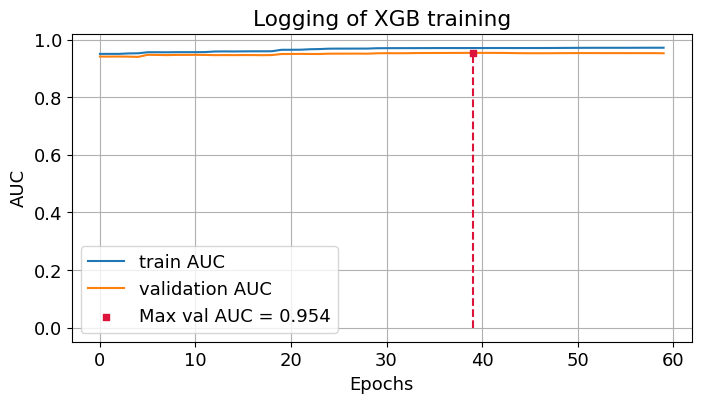

In [269]:
VisualizeLogsWExtrVal(x_Epoch_range if mdl == 'XGB' else c_Epoch_range, x_Train_metrics if mdl == 'XGB' else None,
                      x_Test_metrics if mdl == 'XGB' else c_Test_metrics, x_Keys if mdl == 'XGB' else c_Keys,
                      x_Metrics if mdl == 'XGB' else c_Metrics, x_log_keys if mdl == 'XGB' else c_log_keys,
                      x_log_metrics if mdl == 'XGB' else c_log_metrics, model = mdl, extr = 'Max', save=True, log_path=log_path,
                      image_path=image_path, title = f'{mdl}-{Version}_log_{trees}')

In [245]:
XGB_Classifier.save_model(model_path / f'XGB-{Version}_{trees}.json')

In [251]:
CB_Classifier.save_model(model_path / f'CatB-{Version}_{trees}.cbm')

In [284]:
from sklearn.metrics import roc_auc_score, f1_score
def AUROC_postfactory(model, TestDataset, TestLabels):
    PredictedLabels = model.predict_proba(TestDataset)[:, 1]
    PL_np, TL_np = np.asarray(model.predict(TestDataset)).flatten(), np.asarray(TestLabels).flatten()
    print(f'0\'s: {np.sum(TL_np==0)} - {np.sum(PL_np[TL_np==0]==TL_np[TL_np==0])}')
    print(f'1\'s: {np.sum(TL_np==1)} - {np.sum(PL_np[TL_np==1]==TL_np[TL_np==1])}')
    return roc_auc_score(np.asarray(TestLabels).flatten(), np.asarray(PredictedLabels).flatten())
def F1_postfactory(model, TestDataset, TestLabels):
    PredictedLabels = model.predict(TestDataset)
    return f1_score(np.asarray(TestLabels).flatten(), np.asarray(PredictedLabels).flatten())

In [285]:
AUROC_postfactory(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)

0's: 630 - 0
1's: 2912 - 2912


np.float64(0.9539012079190652)

In [252]:
BoostDict = {'Model': f'{mdl}-{Version}_{trees}',
        'bestTime':  xgbBestTime if mdl == 'XGB' else cbBestTime, 'totalTime': xgbTotalTime if mdl == 'XGB' else cbTotalTime}
BoostDict['AUROCIndex'] = AUROC_postfactory(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)
BoostDict['F1Index'] = F1_postfactory(XGB_Classifier if mdl == 'XGB' else CB_Classifier, TestDataset, TestLabels)
records_file = log_path / 'records.xls'
BoostDF = pd.DataFrame(BoostDict, index=[0])
if not records_file.exists():
    BoostDF.to_excel(records_file, index=False)
else:
    temp = pd.read_excel(records_file)
    last_row = len(temp)
    with pd.ExcelWriter(records_file, mode='a', if_sheet_exists='overlay') as writer:
        BoostDF.to_excel(writer, index=False, header = False, startrow = last_row+1)

In [274]:
def MakePrediction(model, X, Y):
    N = np.random.randint(0, len(X))
    print(f'Истинный buyout_flag: {Y[N][0]}')
    print(f'Предсказанный buyout_flag: {model.predict([X[N]])[0]}')

In [278]:
MakePrediction(XGB_Classifier, TestDataset, TestLabels)

Истинный buyout_flag: 1
Предсказанный buyout_flag: 1


<h1>Нейросетевые модели</h1>

In [138]:
from torch import nn
from torchsummary import summary
#import torchvision
#from torchvision import transforms
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torch.autograd import Variable
#from torch import onnx

In [ ]:
class DatasetNLabels():
  def __init__(self, data, labels, shuffle = False, batch_size = 1):
    self.data = [Variable(th.tensor(i).unsqueeze(0)) for i in data]
    self.labels = [th.tensor(i) for i in labels]
    self.shuffle = shuffle
    self.batch_size = batch_size
  def __len__(self):
    return len(self.data)
  def __getitem__(self, idx):
    return (self.data[idx], self.labels[idx])
  def __iter__(self):
    if self.shuffle:
      perm = np.random.permutation(len(self.data))#, seed = datetime.now().microsecond)
      self.data = [self.data[i] for i in perm]
      self.labels = [self.labels[i] for i in perm]
    for i in range(0, len(self.data), self.batch_size):
      if i + self.batch_size > len(self.data):
        yield (self.data[i:], self.labels[i:])
      else:
        yield (self.data[i:i+self.batch_size], self.labels[i:i+self.batch_size])

In [27]:
shuff = True
batch_size = 200
Train = DatasetNLabels(TrainDataset, TrainLabels, shuffle = shuff, batch_size= batch_size)
del DatasetsTrain, LabelsTrain
gc.collect()
Validation = DatasetNLabels(TestDataset, TestLabels, shuffle = shuff, batch_size= batch_size)
del DatasetsValidation, LabelsValidation
gc.collect()

NameError: name 'DatasetNLabels' is not defined

In [35]:
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
print(device)

cpu


In [31]:
class NNBase(nn.Module):
    def __init__(self, L):
        super(NNBase, self).__init__()
        self.actRL = nn.ReLU()
        self.actTH = nn.Tanh()
        self.actSIG = nn.Sigmoid()
        self.actSM = nn.Softmax(dim=1)
        self.poolMX = nn.MaxPool1d(kernel_size=2, stride=2, return_indices=False)
        self.poolAVG = nn.AvgPool1d(kernel_size=2, stride=2)
        self.lin12 = nn.Linear(L, 2*L)
        self.bnorm1 = nn.BatchNorm1d(num_features = 1)
        self.lin23 = nn.Linear(2*L, 3*L)
        self.bnorm2 = nn.BatchNorm1d(num_features = 1)
        self.lin24 = nn.Linear(2*L, 4*L)
        self.lin31 = nn.Linear(3*L, L)
        self.lin21 = nn.Linear(2*L, L)
        self.bnorm3 = nn.BatchNorm1d(num_features = 1)
        self.lin10 = nn.Linear(L, 1)
        self.bnorm4 = nn.BatchNorm1d(num_features = 1)
        self.dpt = nn.Dropout(p=0.3)
        self.skip = nn.Identity()

In [32]:
class SimpleLinearM1(NNBase):
    def __init__(self, L):
        super(SimpleLinearM1, self).__init__(L)
    def forward(self, x):
        x = self.actRL(self.bnorm1(self.lin12(x)))

        x = self.dpt(self.actRL(self.bnorm2(self.lin23(x))))

        x = self.actRL(self.bnorm3(self.lin31(x)))

        x = self.actSIG(self.dpt(self.bnorm4(self.lin10(x))))
        return x

In [33]:
class SimpleLinearM2(NNBase):
    def init(self, L):
        super(SimpleLinearM2, self).__init__(L)
    def forward(self, x):
        x = self.actRL(self.bnorm1(self.lin12(x)))
        
        res = x.clone()

        x = self.dpt(self.actRL(self.bnorm2(self.lin24(x))))

        x = self.poolMX(x)
        x+=self.skip(res)

        x = self.actRL(self.bnorm3(self.lin21(x)))

        x = self.actSIG(self.dpt(self.bnorm4(self.lin10(x))))
        return x

In [37]:
L = 36
model = SimpleLinearM1(L).to(device)
summary(model, input_size=(1, L))
del model
gc.collect()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 72]           2,664
       BatchNorm1d-2                [-1, 1, 72]               2
              ReLU-3                [-1, 1, 72]               0
            Linear-4               [-1, 1, 108]           7,884
       BatchNorm1d-5               [-1, 1, 108]               2
              ReLU-6               [-1, 1, 108]               0
           Dropout-7               [-1, 1, 108]               0
            Linear-8                [-1, 1, 36]           3,924
       BatchNorm1d-9                [-1, 1, 36]               2
             ReLU-10                [-1, 1, 36]               0
           Linear-11                 [-1, 1, 1]              37
      BatchNorm1d-12                 [-1, 1, 1]               2
          Dropout-13                 [-1, 1, 1]               0
          Sigmoid-14                 [-

NameError: name 'gc' is not defined

In [68]:
modelTitle = 'SimpleLinearM1'
optimizerTitle = 'Adam'

In [ ]:
!pip install torchmetrics
from torchmetrics.classification import BinaryAUROC, BinaryF1Score

In [ ]:
model = SimpleLinearM1().to(device)
optimizer = th.optim.Adam(model.parameters(), lr=0.001)
decayRate = 0.96
lr_scheduler = th.optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=decayRate)
min_running_loss = 999999
patience = 20
curr_patience = patience
bestModel = 0
epochs = 100
startT = datetime.now()
bestTime = 0
totalTime = 0
log_list = {'Epochs': [], 'TrainAUROCLoss': [], 'TrainF1Loss': [],'ValAUROCLoss': [], 'ValF1Loss': []}
train_auroc = BinaryAUROC()
val_auroc = BinaryAUROC()
train_f1 = BinaryF1Score(threshold=0.5)
val_f1 = BinaryF1Score(threshold=0.5)
for epoch in tqdm(range(epochs)):
    AUROCRunningLoss = []
    ValAUROCRunningLoss = []
    F1RunningLoss = []
    ValF1RunningLoss = []
    for inputs, labels in Train:
        optimizer.zero_grad()

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(Variable(inputs.float()))
        AUROCLoss = train_auroc(outputs, labels)
        F1Loss = train_f1(outputs, labels)

        AUROCRunningLoss.append(AUROCLoss.item())
        F1RunningLoss.append(F1Loss.item())

        AUROCLoss.backward()
        optimizer.step()
        lr_scheduler.step()

    for inputs, labels in Validation:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs.float())
        ValAUROCLoss = val_auroc(outputs, labels)
        ValF1Loss = val_f1(outputs, labels)

        ValAUROCRunningLoss.append(ValAUROCLoss.item())
        ValF1RunningLoss.append(ValF1Loss.item())
    log_list['Epochs'].append(epoch)
    log_list['TrainAUROCLoss'].append(np.mean(np.array(AUROCRunningLoss)))
    log_list['TrainF1Loss'].append(np.mean(np.array(F1RunningLoss)))
    log_list['ValAUROCLoss'].append(np.mean(np.array(ValAUROCRunningLoss)))
    log_list['ValF1Loss'].append(np.mean(np.array(ValF1RunningLoss)))
    if np.mean(np.array(ValAUROCRunningLoss)) < min_running_loss:
        min_running_loss = np.mean(np.array(ValAUROCRunningLoss))
        curr_patience = patience
    else:
        if curr_patience == patience:
            endT = datetime.now()
            bestTime = str(endT - startT).split('.')[0]
            bestModel = model
            bestAUROCLoss = np.mean(np.array(ValAUROCRunningLoss))
            bestF1Losses = np.mean(np.array(ValF1RunningLoss))
        curr_patience -= 1
    if curr_patience == 0:
        endT = datetime.now()
        totalTime = str(endT - startT).split('.')[0]
        break
    if epoch == epochs-1:
        endT = datetime.now()
        totalTime = str(endT - startT).split('.')[0]
        if curr_patience == patience:
            bestTime = str(endT - startT).split('.')[0]
            bestModel = model
            bestAUROCLoss = np.mean(np.array(ValAUROCRunningLoss))
            bestF1Losses = np.mean(np.array(ValF1RunningLoss))
th.save(bestModel.state_dict(), model_path / f'{modelTitle}_({optimizerTitle}, {device}).pth')
NNlog = pd.DataFrame(log_list)
NNlog.to_csv(log_path / f'{modelTitle}_({optimizerTitle}, {device}).csv')
NNDict = {'Model': f'{modelTitle}_({optimizerTitle}, {device})',
        'bestTime': bestTime, 'totalTime': totalTime}
NNDict['AUROCIndex'] = bestAUROCLoss
NNDict['F1Index'] = bestF1Losses
NNlog = pd.DataFrame(NNDict, index=[0])
records_file = log_path / 'records.xls'
if not records_file.exists():
    NNlog.to_excel(records_file, index=False)
else:
    temp = pd.read_excel(records_file)
    last_row = len(temp)
    with pd.ExcelWriter(records_file, mode='a', if_sheet_exists='overlay') as writer:
        NNlog.to_excel(writer, index=False, header = False, startrow = last_row+1)

In [ ]:
def NNVisualizeLogsWMinVal(Epoch_range, Train_metrics, Test_metrics, Keys, Metrics, log_keys, log_metrics, model, kernel=None, save=False, log_path = '', image_path = '', title='1'):
  fig, ax = plt.subplots(len(Metrics), figsize = (8, 4*len(Metrics)))
  font = {'font.size': 13}
  plt.rcParams.update(font)
  if len(Metrics) == 1:
    Min_metric = Test_metrics.min()
    Min_epoch = Epoch_range[np.argmin(Test_metrics)]
    ax.plot(Epoch_range, Train_metrics, label = f'{Keys[log_keys[0]]} {Metrics[log_metrics[0]]}', zorder = 2)
    ax.plot(Epoch_range, Test_metrics, label = f'{Keys[log_keys[1]]} {Metrics[log_metrics[0]]}', zorder = 3)
    ax.scatter(Min_epoch, Min_metric, c = 'crimson', marker='s', s=20, label = f'Min val {Metrics[log_metrics[0]]} = {Min_metric:.3f}', zorder = 4)
    ax.plot([Min_epoch, Min_epoch], [0, Min_metric], c = 'crimson', linestyle = '--')
    ax.legend(loc=0)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(Metrics[log_metrics[0]])
    if kernel is not None:
      ax.set_title(f'Logging of {model} training (kernel = {kernel})')
    else:
      ax.set_title(f'Logging of {model} training')
    ax.grid(True, zorder = 1)
  else:
    if kernel is not None:
      ax[0].set_title(f'Logging of {model} training (kernel = {kernel})')
    else:
      ax[0].set_title(f'Logging of {model} training')
    for i, metric in enumerate(log_metrics):
      Min_epoch = Epoch_range[np.argmin(Test_metrics[metric])]
      Min_metric = Test_metrics[metric][Min_epoch]
      ax[i].plot(Epoch_range, Train_metrics[metric], label = f'{Keys[log_keys[0]]} {Metrics[metric]}', zorder = 2)
      ax[i].plot(Epoch_range, Test_metrics[metric], label = f'{Keys[log_keys[1]]} {Metrics[metric]}', zorder = 3)
      ax[i].scatter(Min_epoch, Min_metric, c = 'crimson', marker='s', s=20, label = f'Min val {Metrics[metric]} = {Min_metric:.3f}', zorder = 4)
      ax[i].plot([Min_epoch, Min_epoch], [0, Min_metric], c = 'crimson', linestyle = '--')
      ax[i].legend(loc=0)
      ax[i].set_xlabel('Epochs')
      ax[i].set_ylabel(Metrics[metric])
      ax[i].grid(True, zorder = 1)
  if save:
    Dict = {'Epochs': Epoch_range}
    if len(Metrics) == 1:
      Dict[f'{Keys[log_keys[0]]}_{Metrics[log_metrics[0]]}'] = Train_metrics
      Dict[f'{Keys[log_keys[1]]}_{Metrics[log_metrics[0]]}'] = Test_metrics
    else:
      for metric in log_metrics:
        Dict[f'{Keys[log_keys[0]]}_{Metrics[metric]}'] = Train_metrics[metric]
        Dict[f'{Keys[log_keys[1]]}_{Metrics[metric]}'] = Test_metrics[metric]
    df = pd.DataFrame(Dict)
    df.to_csv(log_path / (title+'.csv'))
    fig.savefig(image_path / (title+'.png'))
  plt.show()

In [ ]:
Epochs = np.array([i for i in NNlog['Epochs'].to_dict().values()])
cols = [i for i in NNlog.columns if i!='Epochs']
Train_metrics = {i[5:]: [j for j in df[i].to_dict().values()] for i in cols if ('Train' in i)}
Test_metrics = {i[3:]: [j for j in df[i].to_dict().values()] for i in cols if ('Val' in i)}
Keys = ['train', 'val']
log_metrics = [i for i in Train_metrics.keys()]
log_keys = [0, 1]
Metrics = {'AUROCLoss': 'ROC-AUC', 'F1Loss': 'F1'}

In [ ]:
NNVisualizeLogsWMinVal(Epochs, Train_metrics, Test_metrics, Keys, Metrics, log_keys,
                     log_metrics, modelTitle.replace('_', ' '), save = False, log_path= log_path,
                     image_path= images_path, title = f'{modelTitle}_log_({optimizerTitle}, {device})')

<h1>Стьюденто- и Фишероподобные критерии</h1>

In [25]:
!pip install shap
import shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/38.1 MB 23.1 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/38.1 MB 29.2 MB/s eta 0:00:01
   ------------------- -------------------- 18.6/38.1 MB 29.4 MB/s eta 0:00:01
   ------------------------ --------------- 23.6/38.1 MB 27.6 MB/s eta 0:00:01
   ----------------------------- ---------- 28.0/38.1 MB 26.5 MB/s eta 0:00:01
   ---------------------------------- ----- 32.8/38.1 MB 25.7 MB/s eta 0:00:01
   ---------------------------------------  37.5/38.1 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 24.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 19.9 MB/s  0:00:00

   -------

In [28]:
from scipy import stats

def tstar_student(alpha, df):
    return stats.t.ppf(1-alpha/2, df)

def create_student_table(alpha_values=[0.1, 0.05, 0.02, 0.01, 0.005], 
                         df_max=30):
    table_data = {}
    
    for alpha in alpha_values:
        column_name = f'α={alpha}'
        column_data = []
        
        for df in range(1, df_max + 1):
            t_critical = stats.t.ppf(1 - alpha/2, df)
            column_data.append(tstar_student(alpha, df))
        
        table_data[column_name] = column_data
    
    df_index = list(range(1, df_max + 1))
    table = pd.DataFrame(table_data, index=df_index)
    table.index.name = 'df'
    
    return table
#Изначально используется критерий Стьюдента для оценки важности признаков. Критерий Фишера используется для оценки значимости модели в целом.
#Напрямую t-критерий для градиентного бустинга рассчитать не получится. Аналоги - permutation importance, SHAP
from sklearn.inspection import permutation_importance
def PerImp(model, X_test, y_test):
    return permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
def SHAP(model, X_test):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    return shap_values
def SSerr(y1, y2):
    return np.sum((y1-y2)**2)
def SSreg(y1, y2):
    return np.sum((y2-np.mean(y1))**2)
def sigj(y1, y2, xj, n, m):
    return np.sqrt(SSerr(y1, y2)/((n-m)*np.sum((xj-np.mean(xj))**2)))
def MSR(y1, y2, m):
    return SSreg(y1, y2)/m
def MSE(y1, y2, n, m):
    return SSerr(y1, y2)/(n-m-1)
def F_test(y1, y2, n, m):
    return MSR(y1, y2, m)/MSE(y1, y2, n, m)
def Fstar_fisher(alpha, df1, df2):
    return stats.f.ppf(1 - alpha, df1, df2)
def create_fisher_table(alpha=0.05, df1_max=30, df2_max=30):
    df1_values = list(range(1, df1_max + 1))
    df2_values = list(range(1, df2_max + 1))
    
    table_data = {}
    
    for df1 in df1_values:
        column_data = []
        for df2 in df2_values:
            column_data.append(Fstar_fisher(alpha, df1, df2))
        table_data[f'df1={df1}'] = column_data
    
    table = pd.DataFrame(table_data, index=df2_values)
    table.index.name = 'df2'
    
    return table